<a href="https://colab.research.google.com/github/Dhanush123555/ML_Escapades/blob/main/CIFAR10_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np


#Transform to normalise all channels to mean 0 and standard deviation 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0, 0, 0), (1, 1, 1))
])


# Load all datasets
tempset = torchvision.datasets.CIFAR10(
    root = "./data",
    train = True,
    download = True,
    transform = transform,
)

testset = torchvision.datasets.CIFAR10(
    root = "./data",
    train = False,
    download = True,
    transform = transform,
)

BATCH_SIZE = 256


# Split train data into train set and val set for hyperparameter tuning
indices = np.arange(len(tempset))
train_ind, val_ind = train_test_split(
    indices,
    test_size = 0.2,
    random_state = 42,
    shuffle = True,
    stratify = tempset.targets,
)

trainset = Subset(tempset, train_ind)
valset = Subset(tempset, val_ind)


# Define all dataloaders
train_dl = DataLoader(
    trainset,
    shuffle = True,
    batch_size = BATCH_SIZE
)

val_dl = DataLoader(
    valset,
    shuffle = False,
    batch_size = BATCH_SIZE
)

test_dl = DataLoader(
    testset,
    shuffle = False,
    batch_size = BATCH_SIZE
)

100%|██████████| 170M/170M [00:06<00:00, 26.7MB/s]


In [ ]:
# Check if data is balanced
els = {}
for tensor, label in trainset:
  if label not in els:
    els[label] = 1
  else:
    els[label] += 1

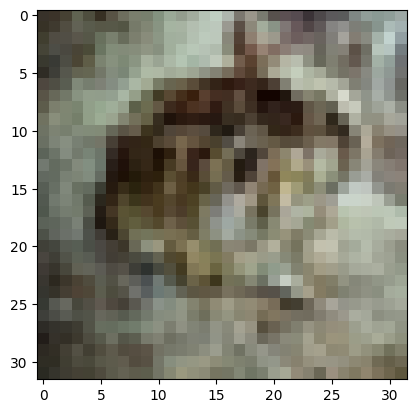

In [2]:
#Plot one image to see how it looks like
import matplotlib.pyplot as plt
import numpy as np

trans = torchvision.transforms.ToPILImage()
out = trans(trainset[0][0])
plt.imshow(np.array(out))
plt.show()

In [3]:
# Classmap for further use
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
class_map = {}
reverse_map = {}

for i, cls in enumerate(classes):
  class_map[i] = cls
  reverse_map[cls] = i

device = torch.device("cuda" if torch.cuda.is_available else "cpu")
device

device(type='cuda')

In [8]:
# Define a VGG style CNN
import torch.nn as nn

class VGGNET(nn.Module):

  def __init__(self):
    super(VGGNET, self).__init__()

    self.conv1 = nn.Conv2d(3, 16, 3, padding = 1)
    self.conv2 = nn.Conv2d(16, 16, 3, padding = 1)
    self.mp = nn.MaxPool2d(2, stride = 2)

    self.conv3 = nn.Conv2d(16, 32, 3, padding = 1)
    self.dp = nn.Dropout2d(0.3)
    self.conv4 = nn.Conv2d(32, 32, 3, padding = 1)


    self.conv5 = nn.Conv2d(32, 64, 3, padding = 1)
    self.conv6 = nn.Conv2d(64, 64, 3, padding = 1)
    self.conv7 = nn.Conv2d(64, 64, 3, padding = 1)

    self.flat = nn.Flatten()
    self.fc_1 = nn.Linear(1024, 1024)
    self.dp_2 = nn.Dropout(0.2)
    self.fc_2 = nn.Linear(1024, 10)

  def forward(self, x):

    x = self.conv1(x)
    x = self.conv2(x)

    x = self.mp(x)

    x = self.conv3(x)
    x = self.dp(x)
    x = self.conv4(x)

    x = self.mp(x)

    x = self.conv5(x)
    x = self.dp(x)
    x = self.conv6(x)
    x = self.dp(x)
    x = self.conv7(x)

    x = self.mp(x)

    x = self.flat(x)
    x = self.fc_1(x)
    x = self.dp_2(x)

    return self.fc_2(x)


# Instansiate and move to cuda device
model = VGGNET()
model.to(device)

VGGNET(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (mp): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dp): Dropout2d(p=0.3, inplace=False)
  (conv4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc_1): Linear(in_features=1024, out_features=1024, bias=True)
  (dp_2): Dropout(p=0.2, inplace=False)
  (fc_2): Linear(in_features=1024, out_features=10, bias=True)
)

In [5]:
# Let's calculate accuracy

def calculate_accuracy(dl):
  model.eval()

  total = 0
  correct = 0
  for batch_x, batch_y in dl:
    batch_x = batch_x.cuda()
    batch_y = batch_y.cuda()

    with torch.no_grad():
      output = model(batch_x)

    pred = torch.argmax(output, dim = 1)
    correct += (pred == batch_y).sum()
    total += batch_y.shape[0]

  return correct / total

In [9]:
from torch. optim import Adam

EPOCHS = 110

optimizer = Adam(model.parameters(), 1e-3)
criterion = nn.CrossEntropyLoss()


#Training loop
for epoch in range(EPOCHS):
  model.train()
  epoch_loss = 0
  for batch_x, batch_y in train_dl:
    batch_x = batch_x.cuda()
    batch_y = batch_y.cuda()

    optimizer.zero_grad()
    output = model(batch_x)
    loss = criterion(output, batch_y)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  if epoch % 5 == 0 :
    print(f"Epoch {epoch} : Training Loss : {epoch_loss} Train accuracy: {calculate_accuracy(train_dl)} Test accuracy: {calculate_accuracy(val_dl)}")


Epoch 0 : Training Loss : 283.05077612400055 Train accuracy: 0.4658999741077423 Test accuracy: 0.4634999930858612
Epoch 5 : Training Loss : 166.4144909977913 Train accuracy: 0.6843499541282654 Test accuracy: 0.6549999713897705
Epoch 10 : Training Loss : 143.66936695575714 Train accuracy: 0.739549994468689 Test accuracy: 0.6887999773025513
Epoch 15 : Training Loss : 131.16016906499863 Train accuracy: 0.7511999607086182 Test accuracy: 0.687999963760376
Epoch 20 : Training Loss : 122.4526931643486 Train accuracy: 0.7930999994277954 Test accuracy: 0.708899974822998
Epoch 25 : Training Loss : 117.45027679204941 Train accuracy: 0.8053999543190002 Test accuracy: 0.708299994468689
Epoch 30 : Training Loss : 112.9308397769928 Train accuracy: 0.8290999531745911 Test accuracy: 0.724399983882904
Epoch 35 : Training Loss : 109.23869442939758 Train accuracy: 0.838949978351593 Test accuracy: 0.7227999567985535
Epoch 40 : Training Loss : 106.0974417924881 Train accuracy: 0.843874990940094 Test accurac

In [10]:
def predict(model, test_dl):
  model.eval()

  pred_y = torch.empty((0,))
  for batch_x, batch_y in test_dl:
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)

    with torch.no_grad():
      output = model(batch_x)

    pred = torch.argmax(output, dim = 1)
    pred = pred.to(torch.device("cpu"))
    pred_y = torch.cat((pred_y, pred), dim = 0)

  return pred_y

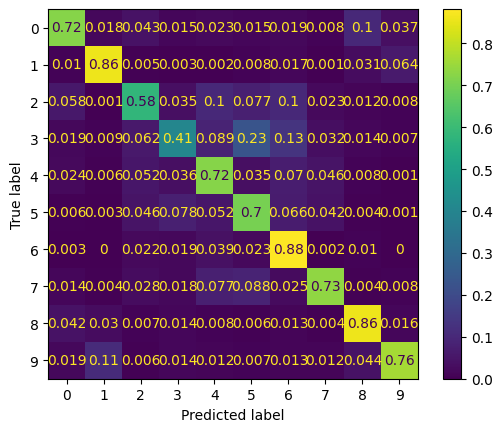

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_true = testset.targets
y_pred = predict(model, test_dl)

cm = confusion_matrix(y_true, y_pred, normalize = 'true', labels = range(10))
disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= range(10))

disp.plot()
plt.show()

In [12]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.72      0.75      1000
           1       0.83      0.86      0.84      1000
           2       0.68      0.58      0.63      1000
           3       0.64      0.41      0.50      1000
           4       0.64      0.72      0.68      1000
           5       0.59      0.70      0.64      1000
           6       0.66      0.88      0.75      1000
           7       0.81      0.73      0.77      1000
           8       0.79      0.86      0.82      1000
           9       0.84      0.76      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000

